In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Loading datasets, augmenting training data

In [8]:
import os
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from PIL import Image
from torch import nn, optim

# Define paths for train dataset
train_dir = '/content/drive/MyDrive/Master Folder/train'
val_dir = '/content/drive/MyDrive/Master Folder/valid'
test_dir = '/content/drive/MyDrive/Master Folder/test'
train_augmented_dir = '/content/drive/MyDrive/Master Folder/train_augmented'

transform = transforms.Compose([
    transforms.Resize((299, 299)),  # Resize images to 224x224 (adjust as needed)
    transforms.ToTensor(),          # Convert images to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize using ImageNet stats (can adjust)
])
"""
# Create a directory to store the augmented dataset
os.makedirs(train_augmented_dir, exist_ok=True)

# Define the augmentations
augmentation_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
])

# Function to save augmented images
def save_augmented_images(dataset, save_dir, num_augmentations=3):
    for class_name in dataset.classes:
        class_dir = os.path.join(save_dir, class_name)
        os.makedirs(class_dir, exist_ok=True)

    for idx, (img, label) in enumerate(dataset):
        class_name = dataset.classes[label]
        original_path = os.path.join(save_dir, class_name, f"original_{idx}.jpg")
        img.save(original_path)  # Save original image

        for i in range(num_augmentations):
            augmented_img = augmentation_transform(img)  # Apply augmentations
            augmented_path = os.path.join(save_dir, class_name, f"augmented_{idx}_{i}.jpg")
            augmented_img.save(augmented_path)

train_dataset = datasets.ImageFolder(root=train_dir)
save_augmented_images(train_dataset, train_augmented_dir, num_augmentations=3)
"""
train_augmented_dataset = datasets.ImageFolder(root=train_augmented_dir, transform=transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

train_loader = DataLoader(train_augmented_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

print("Training dataset length:", len(train_augmented_dataset))
print("Validation dataset length:", len(val_dataset))
print("Test dataset length:", len(test_dataset))

Training dataset length: 4000
Validation dataset length: 36
Test dataset length: 38


# Visualizing samples of the training dataset

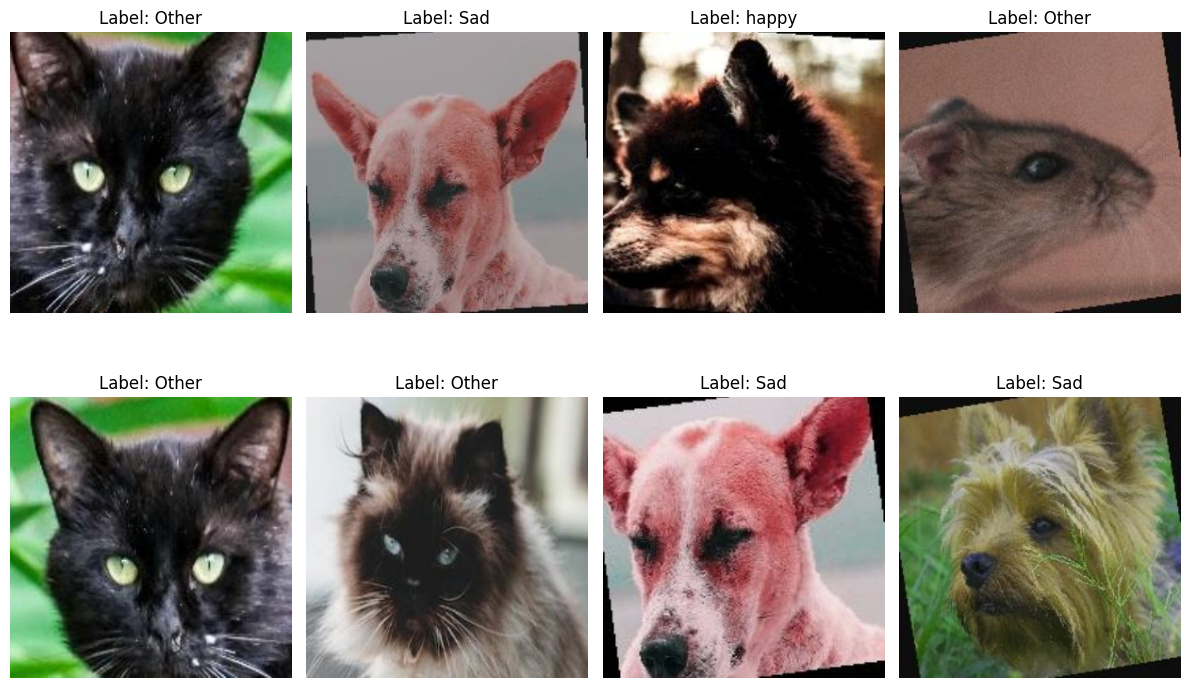

In [9]:
import matplotlib.pyplot as plt
import torchvision.transforms as T

# Define an inverse transform to undo normalization for visualization
inv_transform = T.Compose([
    T.Normalize(mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225], std=[1/0.229, 1/0.224, 1/0.225]),
    T.ToPILImage()
])

# Fetch a single batch of images and labels
data_iter = iter(train_loader)
images, labels = next(data_iter)

# Plot sample images
plt.figure(figsize=(12, 8))
for i in range(8):  # Display the first 8 images in the batch
    img = inv_transform(images[i])  # Undo normalization for visualization
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Label: {train_augmented_dataset.classes[labels[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Model architecture

In [10]:
# Copyright 2022 Dakewe Biotech Corporation. All Rights Reserved.
# Licensed under the Apache License, Version 2.0 (the "License");
#   you may not use this file except in compliance with the License.
#   You may obtain a copy of the License at
#
#       http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.
# ==============================================================================
from collections import namedtuple
from typing import Optional, Any

import torch
from torch import Tensor
from torch import nn

__all__ = [
    "InceptionV3Outputs",
    "InceptionV3",
    "BasicConv2d", "InceptionA", "InceptionB", "InceptionC", "InceptionD", "InceptionE", "InceptionA", "InceptionAux",
    "inception_v3",
]

# According to the writing of the official library of Torchvision
InceptionV3Outputs = namedtuple("InceptionV3Outputs", ["logits", "aux_logits", ])
InceptionV3Outputs.__annotations__ = {"logits": Tensor, "aux_logits": Optional[Tensor]}


class InceptionV3(nn.Module):
    __constants__ = ["aux_logits", "transform_input"]

    def __init__(
            self,
            num_classes: int = 1000,
            aux_logits: bool = True,
            transform_input: bool = False,
            dropout: float = 0.5,
    ) -> None:
        super(InceptionV3, self).__init__()
        self.aux_logits = aux_logits
        self.transform_input = transform_input

        self.Conv2d_1a_3x3 = BasicConv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(0, 0))
        self.Conv2d_2a_3x3 = BasicConv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(0, 0))
        self.Conv2d_2b_3x3 = BasicConv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        self.maxpool1 = nn.MaxPool2d((3, 3), (2, 2))
        self.Conv2d_3b_1x1 = BasicConv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), padding=(0, 0))
        self.Conv2d_4a_3x3 = BasicConv2d(80, 192, kernel_size=(3, 3), stride=(1, 1), padding=(0, 0))
        self.maxpool2 = nn.MaxPool2d((3, 3), (2, 2))

        self.Mixed_5b = InceptionA(192, 32)
        self.Mixed_5c = InceptionA(256, 64)
        self.Mixed_5d = InceptionA(288, 64)

        self.Mixed_6a = InceptionB(288)

        self.Mixed_6b = InceptionC(768, 128)
        self.Mixed_6c = InceptionC(768, 160)
        self.Mixed_6d = InceptionC(768, 160)
        self.Mixed_6e = InceptionC(768, 192)

        if aux_logits:
            self.aux = InceptionAux(768, num_classes)
        else:
            self.aux = None

        self.Mixed_7a = InceptionD(768)
        self.Mixed_7b = InceptionE(1280)
        self.Mixed_7c = InceptionE(2048)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout, True)
        self.fc = nn.Linear(2048, num_classes)

        # Initialize neural network weights
        self._initialize_weights()

    @torch.jit.unused
    def eager_outputs(self, x: Tensor, aux: Optional[Tensor]) -> InceptionV3Outputs | Tensor:
        if self.training and self.aux_logits:
            return InceptionV3Outputs(x, aux)
        else:
            return x

    def forward(self, x: Tensor) -> InceptionV3Outputs | Tensor:
        out = self._forward_impl(x)

        return out

    def _transform_input(self, x: Tensor) -> Tensor:
        if self.transform_input:
            x_ch0 = torch.unsqueeze(x[:, 0], 1) * (0.229 / 0.5) + (0.485 - 0.5) / 0.5
            x_ch1 = torch.unsqueeze(x[:, 1], 1) * (0.224 / 0.5) + (0.456 - 0.5) / 0.5
            x_ch2 = torch.unsqueeze(x[:, 2], 1) * (0.225 / 0.5) + (0.406 - 0.5) / 0.5
            x = torch.cat((x_ch0, x_ch1, x_ch2), 1)
        return x

    # Support torch.script function
    def _forward_impl(self, x: Tensor) -> InceptionV3Outputs:
        x = self._transform_input(x)

        out = self.Conv2d_1a_3x3(x)
        out = self.Conv2d_2a_3x3(out)
        out = self.Conv2d_2b_3x3(out)
        out = self.maxpool1(out)
        out = self.Conv2d_3b_1x1(out)
        out = self.Conv2d_4a_3x3(out)
        out = self.maxpool2(out)

        out = self.Mixed_5b(out)
        out = self.Mixed_5c(out)
        out = self.Mixed_5d(out)

        out = self.Mixed_6a(out)

        out = self.Mixed_6b(out)
        out = self.Mixed_6c(out)
        out = self.Mixed_6d(out)
        out = self.Mixed_6e(out)

        aux1: Optional[Tensor] = None
        if self.aux is not None:
            if self.training:
                aux1 = self.aux(out)

        out = self.Mixed_7a(out)

        out = self.Mixed_7b(out)
        out = self.Mixed_7c(out)

        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.dropout(out)
        aux2 = self.fc(out)

        if torch.jit.is_scripting():
            return InceptionV3Outputs(aux2, aux1)
        else:
            return self.eager_outputs(aux2, aux1)

    def _initialize_weights(self) -> None:
        for module in self.modules():
            if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
                stddev = float(module.stddev) if hasattr(module, "stddev") else 0.1
                torch.nn.init.trunc_normal_(module.weight, mean=0.0, std=stddev, a=-2, b=2)
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.constant_(module.weight, 1)
                nn.init.constant_(module.bias, 0)


class BasicConv2d(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, **kwargs: Any) -> None:
        super(BasicConv2d, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.bn = nn.BatchNorm2d(out_channels, eps=0.001)
        self.relu = nn.ReLU(True)

    def forward(self, x: Tensor) -> Tensor:
        out = self.conv(x)
        out = self.bn(out)
        out = self.relu(out)

        return out


class InceptionA(nn.Module):
    def __init__(
            self,
            in_channels: int,
            pool_features: int,
    ) -> None:
        super(InceptionA, self).__init__()
        self.branch1x1 = BasicConv2d(in_channels, 64, kernel_size=(1, 1), stride=(1, 1), padding=(0, 0))

        self.branch5x5_1 = BasicConv2d(in_channels, 48, kernel_size=(1, 1), stride=(1, 1), padding=(0, 0))
        self.branch5x5_2 = BasicConv2d(48, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))

        self.branch3x3dbl_1 = BasicConv2d(in_channels, 64, kernel_size=(1, 1), stride=(1, 1), padding=(0, 0))
        self.branch3x3dbl_2 = BasicConv2d(64, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        self.branch3x3dbl_3 = BasicConv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

        self.branch_pool = BasicConv2d(in_channels, pool_features, kernel_size=(1, 1), stride=(1, 1), padding=(0, 0))
        self.avgpool = nn.AvgPool2d((3, 3), (1, 1), (1, 1))

    def forward(self, x: Tensor) -> Tensor:
        branch1x1 = self.branch1x1(x)

        branch5x5 = self.branch5x5_1(x)
        branch5x5 = self.branch5x5_2(branch5x5)

        branch3x3dbl = self.branch3x3dbl_1(x)
        branch3x3dbl = self.branch3x3dbl_2(branch3x3dbl)
        branch3x3dbl = self.branch3x3dbl_3(branch3x3dbl)

        branch_pool = self.avgpool(x)
        branch_pool = self.branch_pool(branch_pool)

        out = [branch1x1, branch5x5, branch3x3dbl, branch_pool]
        out = torch.cat(out, 1)

        return out


class InceptionB(nn.Module):
    def __init__(
            self,
            in_channels: int,
    ) -> None:
        super(InceptionB, self).__init__()

        self.branch3x3 = BasicConv2d(in_channels, 384, kernel_size=(3, 3), stride=(2, 2), padding=(0, 0))

        self.branch3x3dbl_1 = BasicConv2d(in_channels, 64, kernel_size=(1, 1), stride=(1, 1), padding=(0, 0))
        self.branch3x3dbl_2 = BasicConv2d(64, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        self.branch3x3dbl_3 = BasicConv2d(96, 96, kernel_size=(3, 3), stride=(2, 2), padding=(0, 0))

        self.maxpool = nn.MaxPool2d((3, 3), (2, 2))

    def forward(self, x: Tensor) -> Tensor:
        branch3x3 = self.branch3x3(x)

        branch3x3dbl = self.branch3x3dbl_1(x)
        branch3x3dbl = self.branch3x3dbl_2(branch3x3dbl)
        branch3x3dbl = self.branch3x3dbl_3(branch3x3dbl)

        branch_pool = self.maxpool(x)

        out = [branch3x3, branch3x3dbl, branch_pool]
        out = torch.cat(out, 1)

        return out


class InceptionC(nn.Module):
    def __init__(
            self,
            in_channels: int,
            channels_7x7: int,
    ) -> None:
        super(InceptionC, self).__init__()
        self.branch1x1 = BasicConv2d(in_channels, 192, kernel_size=1)

        self.branch7x7_1 = BasicConv2d(in_channels, channels_7x7, kernel_size=(1, 1), stride=(1, 1), padding=(0, 0))
        self.branch7x7_2 = BasicConv2d(channels_7x7, channels_7x7, kernel_size=(1, 7), stride=(1, 1), padding=(0, 3))
        self.branch7x7_3 = BasicConv2d(channels_7x7, 192, kernel_size=(7, 1), stride=(1, 1), padding=(3, 0))

        self.branch7x7dbl_1 = BasicConv2d(in_channels, channels_7x7, kernel_size=1)
        self.branch7x7dbl_2 = BasicConv2d(channels_7x7, channels_7x7, kernel_size=(7, 1), stride=(1, 1), padding=(3, 0))
        self.branch7x7dbl_3 = BasicConv2d(channels_7x7, channels_7x7, kernel_size=(1, 7), stride=(1, 1), padding=(0, 3))
        self.branch7x7dbl_4 = BasicConv2d(channels_7x7, channels_7x7, kernel_size=(7, 1), stride=(1, 1), padding=(3, 0))
        self.branch7x7dbl_5 = BasicConv2d(channels_7x7, 192, kernel_size=(1, 7), stride=(1, 1), padding=(0, 3))

        self.avgpool = nn.AvgPool2d((3, 3), (1, 1), (1, 1))
        self.branch_pool = BasicConv2d(in_channels, 192, kernel_size=(1, 1), stride=(1, 1), padding=(0, 0))

    def forward(self, x: Tensor) -> Tensor:
        branch1x1 = self.branch1x1(x)

        branch7x7 = self.branch7x7_1(x)
        branch7x7 = self.branch7x7_2(branch7x7)
        branch7x7 = self.branch7x7_3(branch7x7)

        branch7x7dbl = self.branch7x7dbl_1(x)
        branch7x7dbl = self.branch7x7dbl_2(branch7x7dbl)
        branch7x7dbl = self.branch7x7dbl_3(branch7x7dbl)
        branch7x7dbl = self.branch7x7dbl_4(branch7x7dbl)
        branch7x7dbl = self.branch7x7dbl_5(branch7x7dbl)

        branch_pool = self.avgpool(x)
        branch_pool = self.branch_pool(branch_pool)

        out = [branch1x1, branch7x7, branch7x7dbl, branch_pool]
        out = torch.cat(out, 1)

        return out


class InceptionD(nn.Module):
    def __init__(
            self,
            in_channels: int,
    ) -> None:
        super(InceptionD, self).__init__()
        self.branch3x3_1 = BasicConv2d(in_channels, 192, kernel_size=(1, 1), stride=(1, 1), padding=(0, 0))
        self.branch3x3_2 = BasicConv2d(192, 320, kernel_size=(3, 3), stride=(2, 2), padding=(0, 0))

        self.branch7x7x3_1 = BasicConv2d(in_channels, 192, kernel_size=(1, 1), stride=(1, 1), padding=(0, 0))
        self.branch7x7x3_2 = BasicConv2d(192, 192, kernel_size=(1, 7), stride=(1, 1), padding=(0, 3))
        self.branch7x7x3_3 = BasicConv2d(192, 192, kernel_size=(7, 1), stride=(1, 1), padding=(3, 0))
        self.branch7x7x3_4 = BasicConv2d(192, 192, kernel_size=(3, 3), stride=(2, 2), padding=(0, 0))

        self.maxpool = nn.MaxPool2d((3, 3), (2, 2))

    def forward(self, x: Tensor) -> Tensor:
        branch3x3 = self.branch3x3_1(x)
        branch3x3 = self.branch3x3_2(branch3x3)

        branch7x7x3 = self.branch7x7x3_1(x)
        branch7x7x3 = self.branch7x7x3_2(branch7x7x3)
        branch7x7x3 = self.branch7x7x3_3(branch7x7x3)
        branch7x7x3 = self.branch7x7x3_4(branch7x7x3)

        branch_pool = self.maxpool(x)

        out = [branch3x3, branch7x7x3, branch_pool]
        out = torch.cat(out, 1)

        return out


class InceptionE(nn.Module):
    def __init__(
            self,
            in_channels: int,
    ) -> None:
        super(InceptionE, self).__init__()
        self.branch1x1 = BasicConv2d(in_channels, 320, kernel_size=(1, 1), stride=(1, 1), padding=(0, 0))

        self.branch3x3_1 = BasicConv2d(in_channels, 384, kernel_size=(1, 1), stride=(1, 1), padding=(0, 0))
        self.branch3x3_2a = BasicConv2d(384, 384, kernel_size=(1, 3), stride=(1, 1), padding=(0, 1))
        self.branch3x3_2b = BasicConv2d(384, 384, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))

        self.branch3x3dbl_1 = BasicConv2d(in_channels, 448, kernel_size=(1, 1), stride=(1, 1), padding=(0, 0))
        self.branch3x3dbl_2 = BasicConv2d(448, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        self.branch3x3dbl_3a = BasicConv2d(384, 384, kernel_size=(1, 3), stride=(1, 1), padding=(0, 1))
        self.branch3x3dbl_3b = BasicConv2d(384, 384, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))

        self.avgpool = nn.AvgPool2d((3, 3), (1, 1), (1, 1))
        self.branch_pool = BasicConv2d(in_channels, 192, kernel_size=1)

    def forward(self, x: Tensor) -> Tensor:
        branch1x1 = self.branch1x1(x)

        branch3x3 = self.branch3x3_1(x)
        branch3x3 = torch.cat([self.branch3x3_2a(branch3x3), self.branch3x3_2b(branch3x3)], 1)

        branch3x3dbl = self.branch3x3dbl_1(x)
        branch3x3dbl = self.branch3x3dbl_2(branch3x3dbl)
        branch3x3dbl = torch.cat([self.branch3x3dbl_3a(branch3x3dbl), self.branch3x3dbl_3b(branch3x3dbl)], 1)

        branch_pool = self.avgpool(x)
        branch_pool = self.branch_pool(branch_pool)

        out = [branch1x1, branch3x3, branch3x3dbl, branch_pool]
        out = torch.cat(out, 1)

        return out


class InceptionAux(nn.Module):
    def __init__(
            self,
            in_channels: int,
            num_classes: int,
    ) -> None:
        super().__init__()
        self.avgpool1 = nn.AvgPool2d((5, 5), (3, 3))
        self.conv0 = BasicConv2d(in_channels, 128, kernel_size=(1, 1), stride=(1, 1), padding=(0, 0))
        self.conv1 = BasicConv2d(128, 768, kernel_size=(5, 5), stride=(1, 1), padding=(0, 0))
        self.avgpool2 = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(768, num_classes)

        self.conv1.stddev = 0.01
        self.fc.stddev = 0.001

    def forward(self, x: Tensor) -> Tensor:
        out = self.avgpool1(x)
        out = self.conv0(out)
        out = self.conv1(out)
        out = self.avgpool2(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)

        return out


def inception_v3(**kwargs: Any) -> InceptionV3:
    model = InceptionV3(**kwargs)

    return model

# Implementation training loop

In [11]:
import torch
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
from tqdm import tqdm

# Initialize the InceptionV3 model
model = InceptionV3(num_classes=4, aux_logits=True)

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
train_accuracies = []
train_precisions = []
train_recalls = []
train_f1s = []
train_conf_matrices = []

val_losses = []
val_accuracies = []
val_precisions = []
val_recalls = []
val_f1s = []
val_conf_matrices = []

# Training loop with progress bar
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    for images, labels in tqdm(dataloader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        logits = outputs.logits if isinstance(outputs, InceptionV3Outputs) else outputs

        # Calculate loss
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Calculate accuracy
        _, preds = torch.max(logits, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # Store predictions and labels for metric calculations
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(dataloader)
    accuracy = correct / total

    # Calculate precision, recall, F1 score, and confusion matrix
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    conf_matrix = confusion_matrix(all_labels, all_preds)

    return avg_loss, accuracy, precision, recall, f1, conf_matrix

# Validation loop with progress bar
def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validation", leave=False):
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            logits = outputs.logits if isinstance(outputs, InceptionV3Outputs) else outputs

            # Calculate loss
            loss = criterion(logits, labels)
            running_loss += loss.item()

            # Calculate accuracy
            _, preds = torch.max(logits, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            # Store predictions and labels for metric calculations
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(dataloader)
    accuracy = correct / total

    # Calculate precision, recall, F1 score, and confusion matrix
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    conf_matrix = confusion_matrix(all_labels, all_preds)

    return avg_loss, accuracy, precision, recall, f1, conf_matrix

# Training loop
def train(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10):
    best_val_accuracy = 0.0
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")

        # Train for one epoch
        train_loss, train_accuracy, train_precision, train_recall, train_f1, train_conf_matrix = train_epoch(model, train_loader, criterion, optimizer, device)
        print(f"Training Loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        train_precisions.append(train_precision)
        train_recalls.append(train_recall)
        train_f1s.append(train_f1)
        train_conf_matrices.append(train_conf_matrix)

        # Validate after training
        val_loss, val_accuracy, val_precision, val_recall, val_f1, val_conf_matrix = validate_epoch(model, val_loader, criterion, device)
        print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
        val_precisions.append(val_precision)
        val_recalls.append(val_recall)
        val_f1s.append(val_f1)
        val_conf_matrices.append(val_conf_matrix)

        # Save the best model based on validation accuracy
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save(model.state_dict(), "best_implemented_inception_v3.pth")
            print("Saved best model!")

# Initialize device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Train the model
train(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=40)

Epoch 1/40


Training Loss: 2.0786, Training Accuracy: 0.2955


Validation:   0%|          | 0/2 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Validation Loss: 0.9725, Validation Accuracy: 0.3056
Saved best model!
Epoch 2/40


Training:   0%|          | 0/125 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


...

Validation Loss: 3.2267, Validation Accuracy: 0.3611
Epoch 40/40


Training:   0%|          | 0/125 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Training Loss: 0.0279, Training Accuracy: 0.9925


Validation:   0%|          | 0/2 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
                                                         

Validation Loss: 4.5338, Validation Accuracy: 0.3056


In [12]:
print("Best validation accuracy", max(val_accuracies))

Best validation accuracy 0.5


# Implementation performance graphs

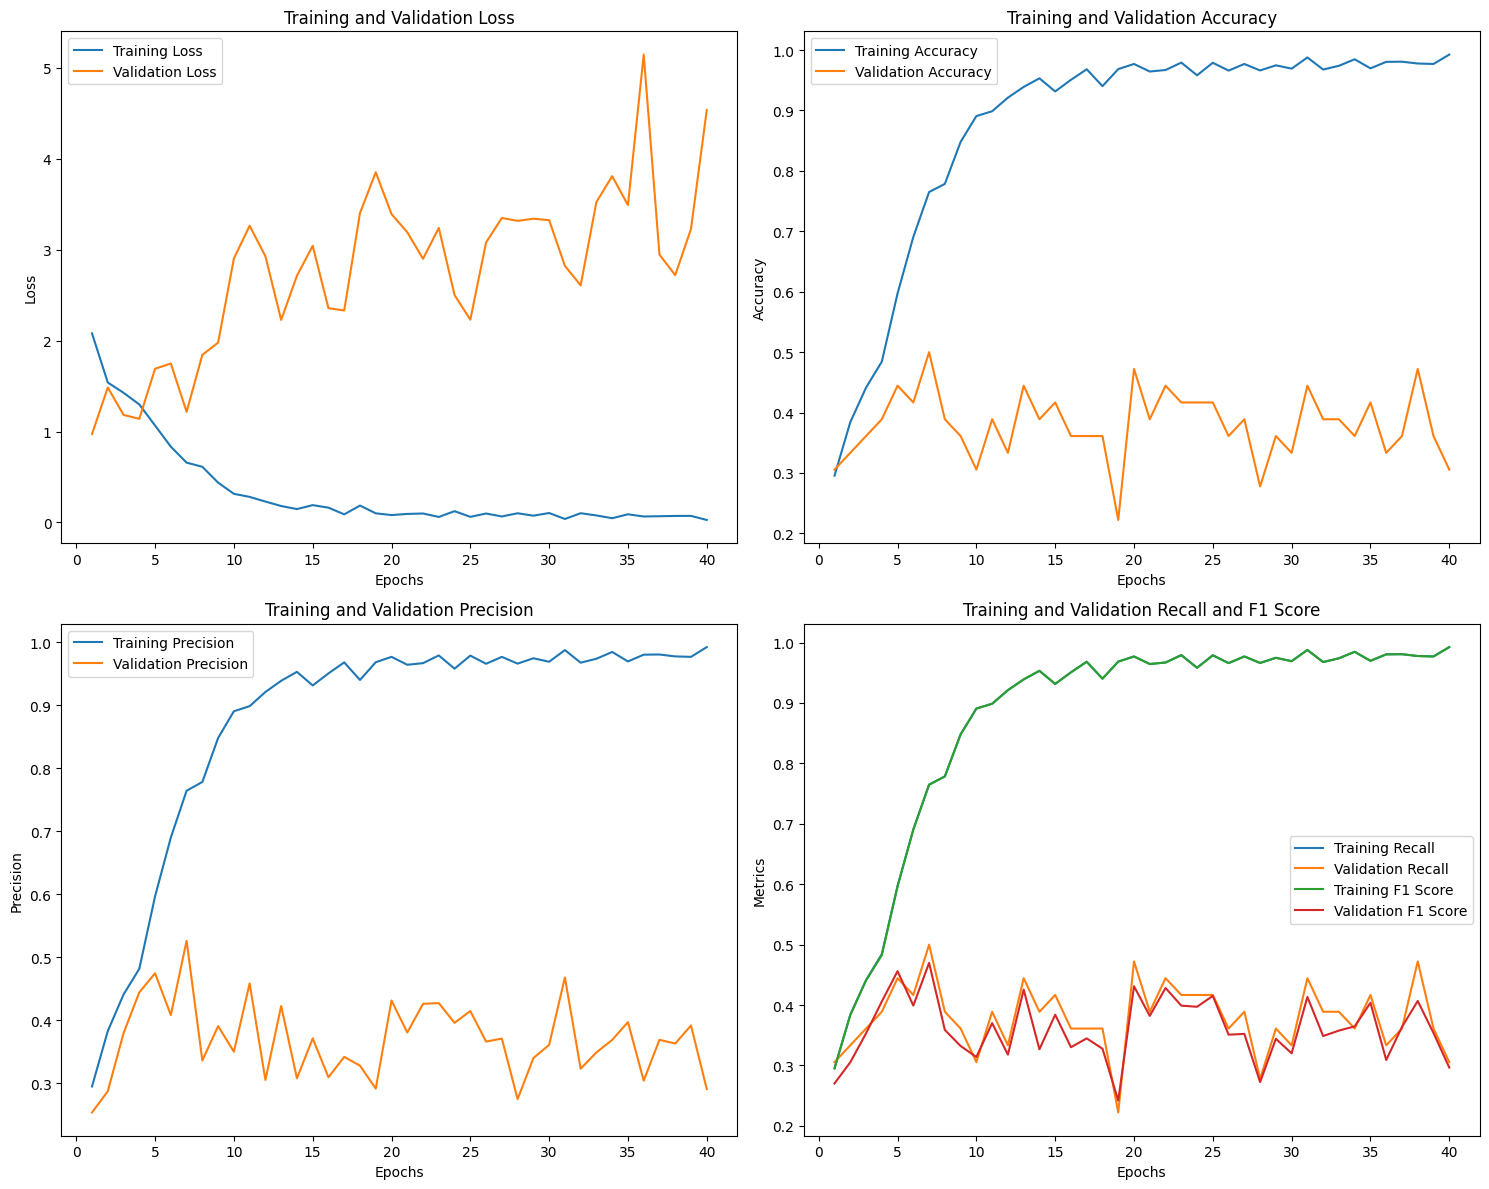

In [13]:
import matplotlib.pyplot as plt

def plot_metrics():
    epochs = range(1, len(train_losses) + 1)

    # Plot training and validation loss
    plt.figure(figsize=(15, 12))

    plt.subplot(2, 2, 1)
    plt.plot(epochs, train_losses, label='Training Loss')
    plt.plot(epochs, val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')

    # Plot training and validation accuracy
    plt.subplot(2, 2, 2)
    plt.plot(epochs, train_accuracies, label='Training Accuracy')
    plt.plot(epochs, val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy')

    # Plot precision, recall, and F1 scores for training and validation
    plt.subplot(2, 2, 3)
    plt.plot(epochs, train_precisions, label='Training Precision')
    plt.plot(epochs, val_precisions, label='Validation Precision')
    plt.xlabel('Epochs')
    plt.ylabel('Precision')
    plt.legend()
    plt.title('Training and Validation Precision')

    plt.subplot(2, 2, 4)
    plt.plot(epochs, train_recalls, label='Training Recall')
    plt.plot(epochs, val_recalls, label='Validation Recall')
    plt.plot(epochs, train_f1s, label='Training F1 Score')
    plt.plot(epochs, val_f1s, label='Validation F1 Score')
    plt.xlabel('Epochs')
    plt.ylabel('Metrics')
    plt.legend()
    plt.title('Training and Validation Recall and F1 Score')

    plt.tight_layout()
    plt.show()

plot_metrics()

# Implementation performance visualization

/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Performance on training images


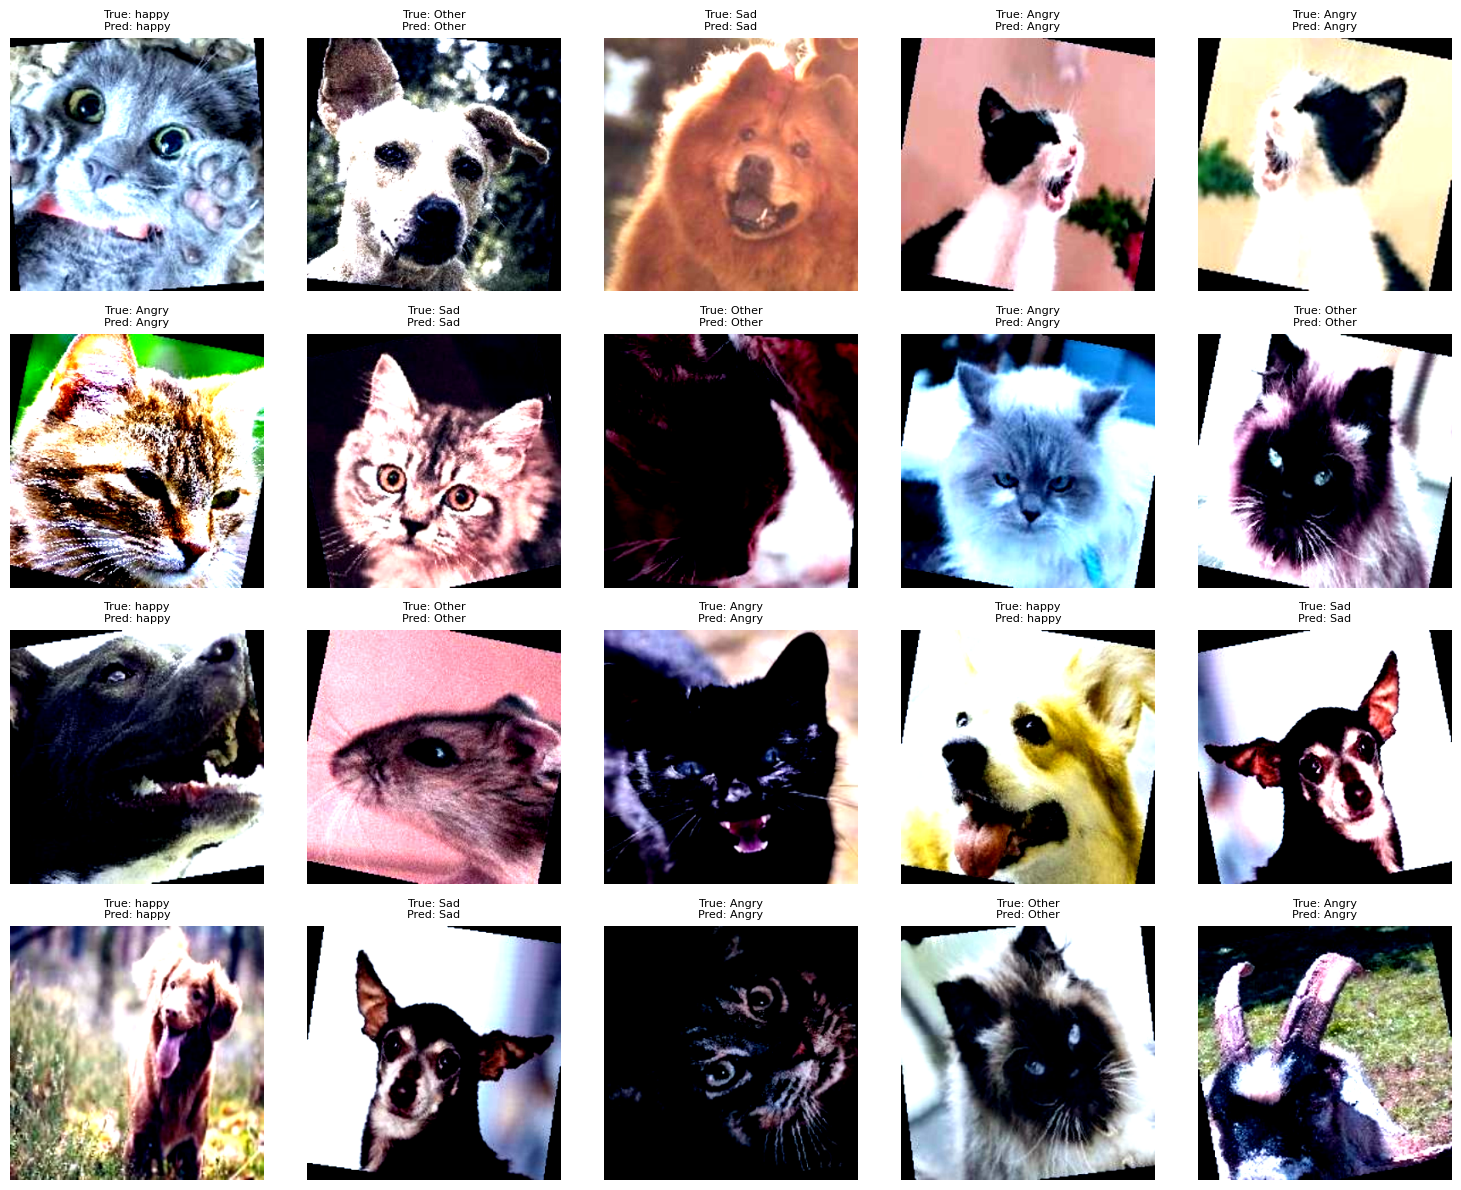

Performance on validation images


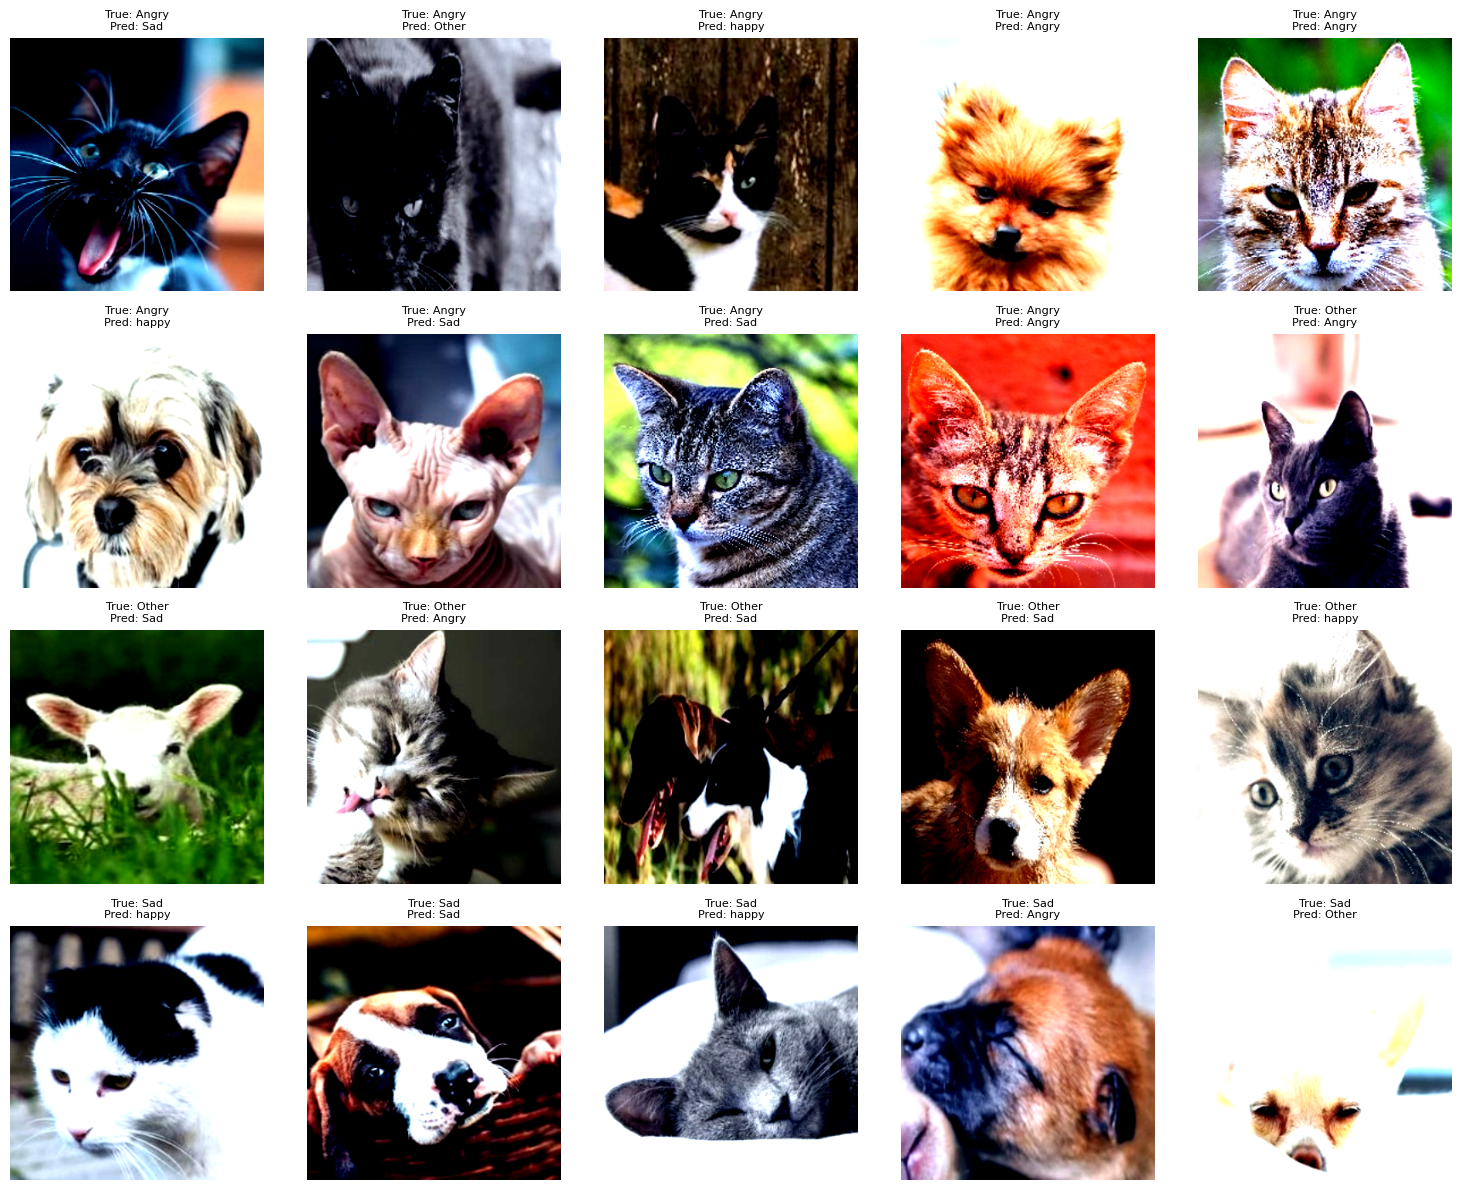

In [14]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from torch.utils.data import DataLoader
from torchvision import transforms

# Define a helper function to display a batch of images in a grid
def show_images_in_grid(images, true_labels, pred_labels, class_names, num_images=20):
    # Create a 4x5 grid
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))
    axes = axes.flatten()  # Flatten the 2D array of axes to make it easier to iterate

    for i in range(num_images):
        image = images[i].permute(1, 2, 0).cpu().numpy()  # Convert to HWC format
        image = (image + 1) / 2 if image.min() < 0 else image  # Rescale if normalized
        image = np.clip(image, 0, 1)  # Ensure image is in the valid range

        # Get true and predicted labels
        true_label = true_labels[i].item()
        pred_label = pred_labels[i]

        # Display the image with its true and predicted labels
        axes[i].imshow(image)
        axes[i].axis('off')  # Hide the axes
        axes[i].set_title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}", fontsize=8)

    plt.tight_layout()  # Adjust layout for better spacing
    plt.show()

# Define function to get predictions from the model
def get_predictions(model, dataloader, device, num_images=20):
    model.eval()
    images = []
    true_labels = []
    pred_labels = []

    # Iterate over the dataloader to get a few examples
    for i, (image_batch, label_batch) in enumerate(dataloader):
        if i == 0:  # Take only the first batch
            images = image_batch[:num_images].to(device)
            true_labels = label_batch[:num_images].to(device)
            outputs = model(images)

            logits = outputs.logits if isinstance(outputs, InceptionV3Outputs) else outputs
            _, predicted = torch.max(logits, 1)
            pred_labels = predicted[:num_images].cpu().numpy()

            break

    return images, true_labels, pred_labels

# Load class names (replace this with the actual class names of your dataset)
class_names = train_augmented_dataset.classes

# Get predictions and display 20 images from the training dataset
train_images, train_labels, train_preds = get_predictions(model, train_loader, device, num_images=20)
print("Performance on training images")
show_images_in_grid(train_images, train_labels, train_preds, class_names, num_images=20)

# Get predictions and display 20 images from the validation dataset
val_images, val_labels, val_preds = get_predictions(model, val_loader, device, num_images=20)
print("Performance on validation images")
show_images_in_grid(val_images, val_labels, val_preds, class_names, num_images=20)

# Pretrained model training loop

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.models import inception_v3
from torchvision.models.inception import InceptionOutputs
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
from tqdm import tqdm

# Load the pretrained Inception V3 model
pretrained_model = inception_v3(pretrained=True, aux_logits=True)

# Modify the final classification layer for the specific number of classes (e.g., 1000 -> 10 for example)
num_classes = 4  # Change this to match your dataset
pretrained_model.fc = nn.Linear(pretrained_model.fc.in_features, num_classes)  # Replace the fully connected layer

# Auxiliary classifier adjustment
if pretrained_model.aux_logits:
    pretrained_model.AuxLogits.fc = nn.Linear(pretrained_model.AuxLogits.fc.in_features, num_classes)

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(pretrained_model.parameters(), lr=0.001)

train_losses = []
train_accuracies = []
train_precisions = []
train_recalls = []
train_f1s = []
train_conf_matrices = []

val_losses = []
val_accuracies = []
val_precisions = []
val_recalls = []
val_f1s = []
val_conf_matrices = []

# Training loop with progress bar
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    for images, labels in tqdm(dataloader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        logits = outputs.logits if isinstance(outputs, InceptionOutputs) else outputs

        # If outputs are an instance of InceptionOutputs (which contains the logits and aux logits)
        if isinstance(outputs, InceptionOutputs):
            logits = outputs.logits

        # Calculate loss
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Calculate accuracy
        _, preds = torch.max(logits, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # Store predictions and labels for metric calculations
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(dataloader)
    accuracy = correct / total

    # Calculate precision, recall, F1 score, and confusion matrix
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    conf_matrix = confusion_matrix(all_labels, all_preds)

    return avg_loss, accuracy, precision, recall, f1, conf_matrix

# Validation loop with progress bar
def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validation", leave=False):
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            logits = outputs.logits if isinstance(outputs, InceptionOutputs) else outputs

            # If outputs are an instance of InceptionOutputs (which contains the logits and aux logits)
            if isinstance(outputs, InceptionOutputs):
                logits = outputs.logits

            # Calculate loss
            loss = criterion(logits, labels)
            running_loss += loss.item()

            # Calculate accuracy
            _, preds = torch.max(logits, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            # Store predictions and labels for metric calculations
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(dataloader)
    accuracy = correct / total

    # Calculate precision, recall, F1 score, and confusion matrix
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    conf_matrix = confusion_matrix(all_labels, all_preds)

    return avg_loss, accuracy, precision, recall, f1, conf_matrix

# Training loop
def train(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10):
    best_val_accuracy = 0.0
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")

        # Train for one epoch
        train_loss, train_accuracy, train_precision, train_recall, train_f1, train_conf_matrix = train_epoch(model, train_loader, criterion, optimizer, device)
        print(f"Training Loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        train_precisions.append(train_precision)
        train_recalls.append(train_recall)
        train_f1s.append(train_f1)
        train_conf_matrices.append(train_conf_matrix)

        # Validate after training
        val_loss, val_accuracy, val_precision, val_recall, val_f1, val_conf_matrix = validate_epoch(model, val_loader, criterion, device)
        print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
        val_precisions.append(val_precision)
        val_recalls.append(val_recall)
        val_f1s.append(val_f1)
        val_conf_matrices.append(val_conf_matrix)

        # Save the best model based on validation accuracy
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save(model.state_dict(), "best_pretrained_inception_v3.pth")
            print("Saved best model!")

# Initialize device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pretrained_model = pretrained_model.to(device)

# Train the model
train(pretrained_model, train_loader, val_loader, criterion, optimizer, device, num_epochs=40)


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 112MB/s] 


Epoch 1/40


Training Loss: 0.9596, Training Accuracy: 0.6120


Validation:   0%|          | 0/2 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Validation Loss: 1.4811, Validation Accuracy: 0.5556
Saved best model!
Epoch 2/40


...

Validation Loss: 3.6616, Validation Accuracy: 0.4167
Epoch 40/40


Training:   0%|          | 0/125 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Training Loss: 0.0359, Training Accuracy: 0.9898


Validation:   0%|          | 0/2 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
                                                         

Validation Loss: 2.9072, Validation Accuracy: 0.5278


In [16]:
print("Best validation accuracy", max(val_accuracies))

Best validation accuracy 0.6111111111111112


# Pretrained model performance graphs

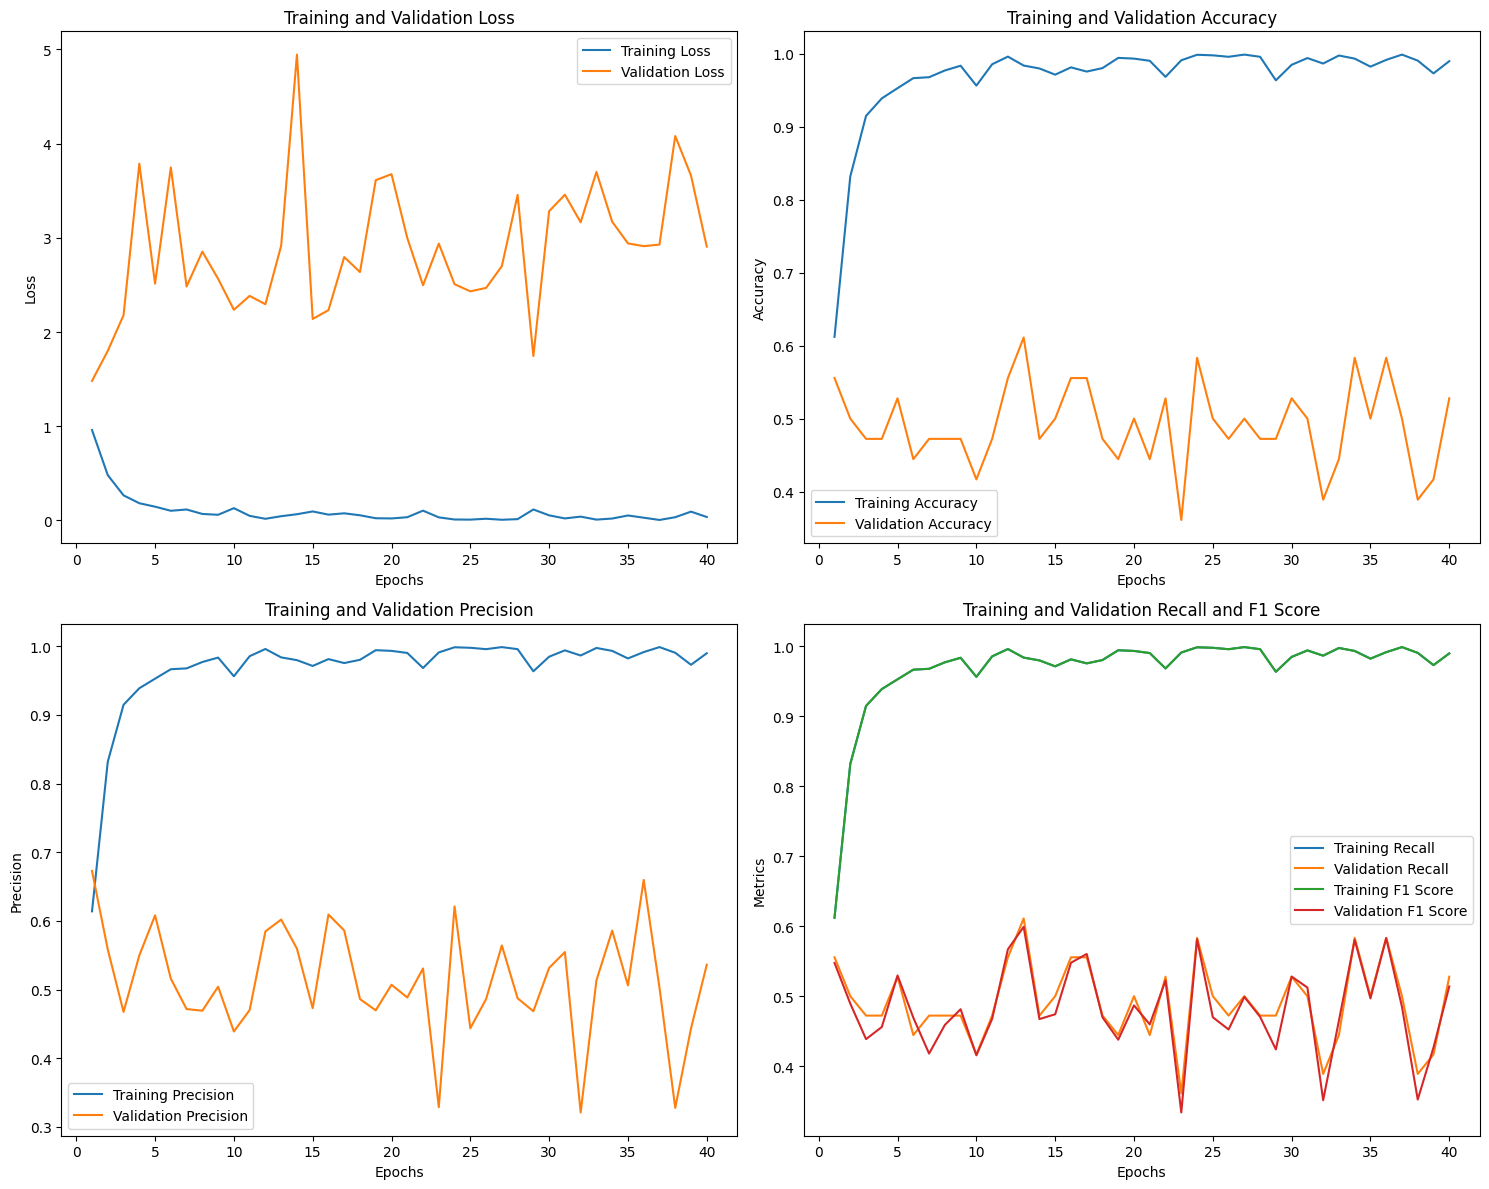

In [17]:
import matplotlib.pyplot as plt

def plot_metrics():
    epochs = range(1, len(train_losses) + 1)

    # Plot training and validation loss
    plt.figure(figsize=(15, 12))

    plt.subplot(2, 2, 1)
    plt.plot(epochs, train_losses, label='Training Loss')
    plt.plot(epochs, val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')

    # Plot training and validation accuracy
    plt.subplot(2, 2, 2)
    plt.plot(epochs, train_accuracies, label='Training Accuracy')
    plt.plot(epochs, val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy')

    # Plot precision, recall, and F1 scores for training and validation
    plt.subplot(2, 2, 3)
    plt.plot(epochs, train_precisions, label='Training Precision')
    plt.plot(epochs, val_precisions, label='Validation Precision')
    plt.xlabel('Epochs')
    plt.ylabel('Precision')
    plt.legend()
    plt.title('Training and Validation Precision')

    plt.subplot(2, 2, 4)
    plt.plot(epochs, train_recalls, label='Training Recall')
    plt.plot(epochs, val_recalls, label='Validation Recall')
    plt.plot(epochs, train_f1s, label='Training F1 Score')
    plt.plot(epochs, val_f1s, label='Validation F1 Score')
    plt.xlabel('Epochs')
    plt.ylabel('Metrics')
    plt.legend()
    plt.title('Training and Validation Recall and F1 Score')

    plt.tight_layout()
    plt.show()

plot_metrics()

# Implementation and pretrained models' performance on test data

## Pretrained model

In [18]:
def evaluate_on_test(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Testing", leave=False):
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            logits = outputs.logits if isinstance(outputs, InceptionV3Outputs) else outputs

            # Calculate loss
            loss = criterion(logits, labels)
            running_loss += loss.item()

            # Calculate accuracy
            _, preds = torch.max(logits, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            # Store predictions and labels for metric calculations
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(test_loader)
    accuracy = correct / total

    # Calculate precision, recall, F1 score, and confusion matrix
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    conf_matrix = confusion_matrix(all_labels, all_preds)

    print(f"\nTest Loss: {avg_loss:.4f}\n Test Accuracy: {accuracy:.4f}")
    print(f"Test Precision: {precision:.4f}\n Test Recall: {recall:.4f}")
    print(f"Test F1 Score: {f1:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}")

model.load_state_dict(torch.load("best_implemented_inception_v3.pth"))
model = model.to(device)

pretrained_model.load_state_dict(torch.load("best_pretrained_inception_v3.pth"))
pretrained_model = pretrained_model.to(device)

print("Implemented model performance: ")
evaluate_on_test(model, test_loader, criterion, device)

print("\nPretrained model performance: ")
evaluate_on_test(pretrained_model, test_loader, criterion, device)

<ipython-input-18-50108eaa7f45>:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_implemented_inception_v3.pth"))
<ipython-input-18-50

Implemented model performance: 


Testing:   0%|          | 0/2 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(



Test Loss: 3.0588
 Test Accuracy: 0.3947
Test Precision: 0.4229
 Test Recall: 0.3947
Test F1 Score: 0.3798
Confusion Matrix:
[[4 2 2 2]
 [1 3 0 2]
 [1 2 2 6]
 [3 2 0 6]]

Pretrained model performance: 


Testing:   0%|          | 0/2 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
                                                      


Test Loss: 3.3126
 Test Accuracy: 0.3421
Test Precision: 0.3803
 Test Recall: 0.3421
Test F1 Score: 0.3439
Confusion Matrix:
[[4 0 4 2]
 [0 0 6 0]
 [0 3 5 3]
 [2 1 4 4]]
